# Import Libraries 

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [20]:
df = pd.read_csv("ai-adoption-fortune500-synthetic-dataset-2020-2025.csv", delimiter=',')

print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
print("df.dtypes: ", df.dtypes)
df.isnull().sum()

df:        Year             Company    Industry Country Company_Type Employee_Size  \
0     2020              Amazon  E-commerce     USA         Real    Enterprise   
1     2021              Amazon  E-commerce     USA         Real    Enterprise   
2     2022              Amazon  E-commerce     USA         Real    Enterprise   
3     2023              Amazon  E-commerce     USA         Real    Enterprise   
4     2024              Amazon  E-commerce     USA         Real    Enterprise   
...    ...                 ...         ...     ...          ...           ...   
5995  2021  SyntheticCorp_0980     Telecom  Brazil    Synthetic    Enterprise   
5996  2022  SyntheticCorp_0980     Finance   India    Synthetic           SME   
5997  2023  SyntheticCorp_0980  Technology  Canada    Synthetic    Enterprise   
5998  2024  SyntheticCorp_0980   Logistics     UAE    Synthetic    Enterprise   
5999  2025  SyntheticCorp_0980  Healthcare   Japan    Synthetic           SME   

       Revenue_USD Use

Year                    0
Company                 0
Industry                0
Country                 0
Company_Type            0
Employee_Size           0
Revenue_USD             0
Uses_AI                 0
Use_Case             1152
AI_ROI_Percent          0
AI_Maturity_Score       0
dtype: int64

# Feature Selection

In [21]:
target = 'AI_Maturity_Score'
features = ['Year', 'Revenue_USD', 'AI_ROI_Percent']

X = df[features]
y = df[target]

# Train Test Split Function

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scaling 

In [23]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models

In [24]:
# 1. DECISION TREE REGRESSOR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dt = DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

# Metrics
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred_dt)


print("="*60)
print("DECISION TREE REGRESSOR RESULTS")
print("="*60)
print(f"MAE:  {dt_mae:.2f}")
print(f"MSE:  {dt_mse:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"R²:   {dt_r2:.4f}")

# 2. RANDOM FOREST REGRESSOR

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)


print("\n" + "="*60)
print("RANDOM FOREST REGRESSOR RESULTS")
print("="*60)
print(f"MAE:  {rf_mae:.2f}")
print(f"MSE:  {rf_mse:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²:   {rf_r2:.4f}")


# 3. GRADIENT BOOSTING REGRESSOR

from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

# Metrics
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, y_pred_gb)


print("\n" + "="*60)
print("GRADIENT BOOSTING REGRESSOR RESULTS")
print("="*60)
print(f"MAE:  {gb_mae:.2f}")
print(f"MSE:  {gb_mse:.2f}")
print(f"RMSE: {gb_rmse:.2f}")
print(f"R²:   {gb_r2:.4f}")


DECISION TREE REGRESSOR RESULTS
MAE:  11.72
MSE:  189.42
RMSE: 13.76
R²:   0.5909

RANDOM FOREST REGRESSOR RESULTS
MAE:  11.26
MSE:  170.92
RMSE: 13.07
R²:   0.6309

GRADIENT BOOSTING REGRESSOR RESULTS
MAE:  11.42
MSE:  177.90
RMSE: 13.34
R²:   0.6158


# Model Comparison 

In [25]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MAE': [dt_mae, rf_mae, gb_mae],
    'MSE': [dt_mse, rf_mse, gb_mse],
    'RMSE': [dt_rmse, rf_rmse, gb_rmse],
    'R²': [dt_r2, rf_r2, gb_r2]
})

print("MODEL COMPARISON SUMMARY")
print(comparison.to_string(index=False))

MODEL COMPARISON SUMMARY
            Model       MAE        MSE      RMSE       R²
    Decision Tree 11.723317 189.423770 13.763131 0.590925
    Random Forest 11.255046 170.916512 13.073504 0.630893
Gradient Boosting 11.416484 177.900815 13.337946 0.615809


# Visualization

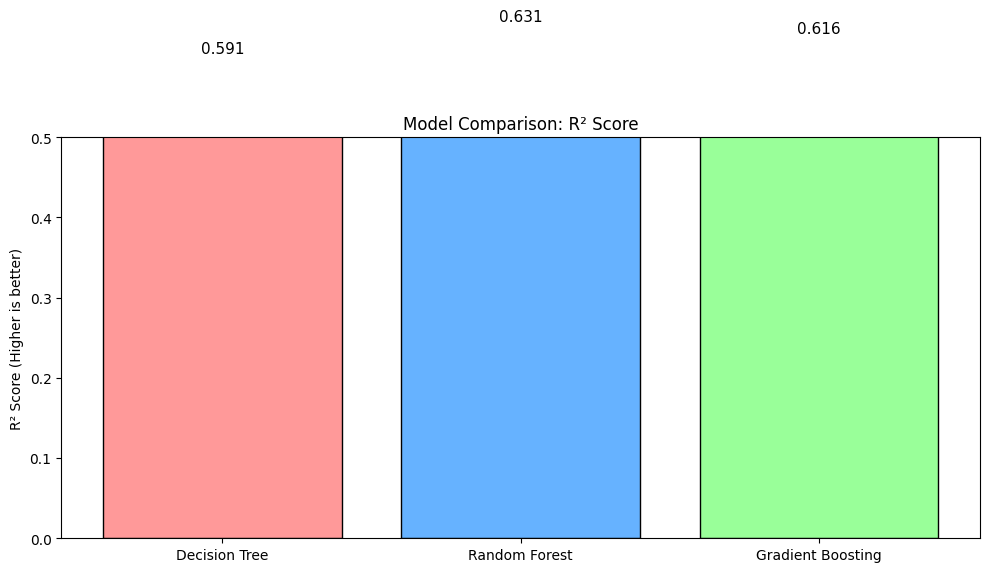

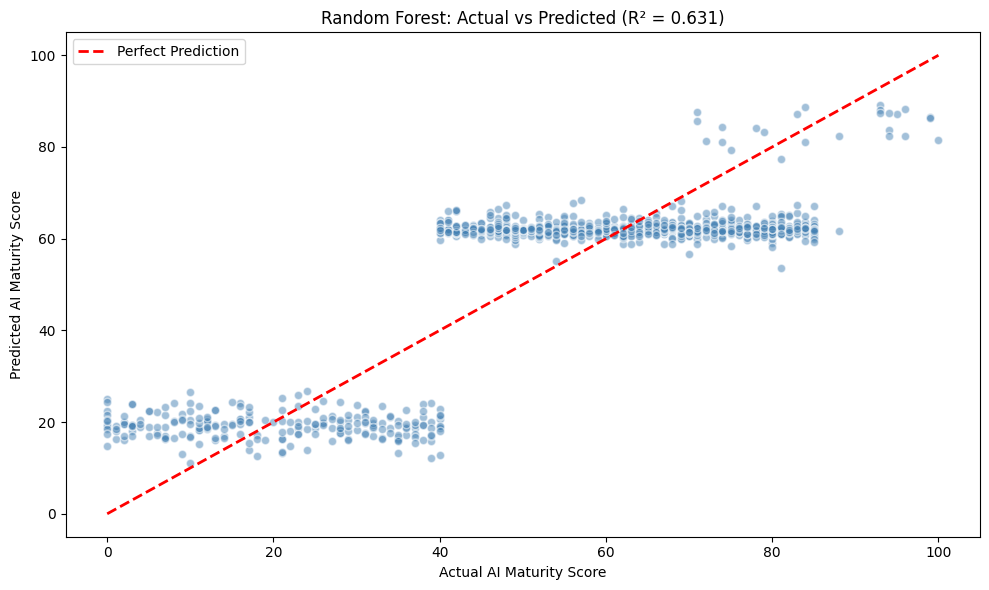

In [26]:
# R² Score Comparison

plt.figure(figsize=(10, 6))
bars = plt.bar(comparison['Model'], comparison['R²'], 
               color=['#FF9999', '#66B2FF', '#99FF99'], edgecolor='black')
plt.ylim(0, 0.5)
plt.ylabel('R² Score (Higher is better)')
plt.title('Model Comparison: R² Score')
for bar, val in zip(bars, comparison['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


#Actual Vs Predicted Plot

best_model_name = comparison.loc[comparison['R²'].idxmax(), 'Model']
if best_model_name == 'Decision Tree':
    best_pred = y_pred_dt
elif best_model_name == 'Random Forest':
    best_pred = y_pred_rf
else:
    best_pred = y_pred_gb

plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_pred, alpha=0.5, c='steelblue', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual AI Maturity Score')
plt.ylabel('Predicted AI Maturity Score')
plt.title(f'{best_model_name}: Actual vs Predicted (R² = {comparison.loc[comparison["R²"].idxmax(), "R²"]:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# Residual Plot

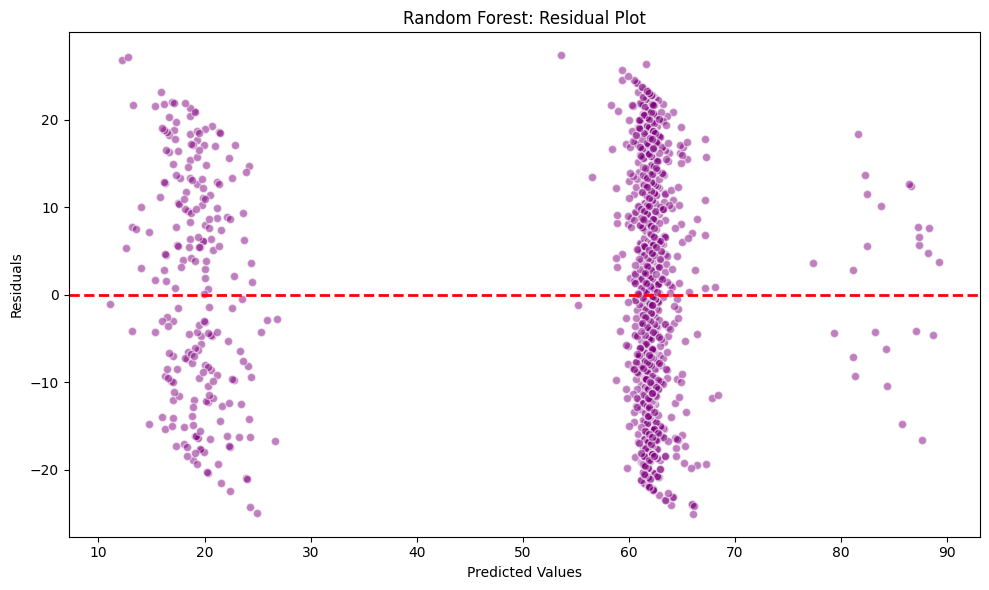

In [27]:
residuals = y_test - best_pred
plt.figure(figsize=(10, 6))
plt.scatter(best_pred, residuals, alpha=0.5, c='purple', edgecolors='white')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title(f'{best_model_name}: Residual Plot')
plt.tight_layout()
plt.show()

# Heatmap Metrics

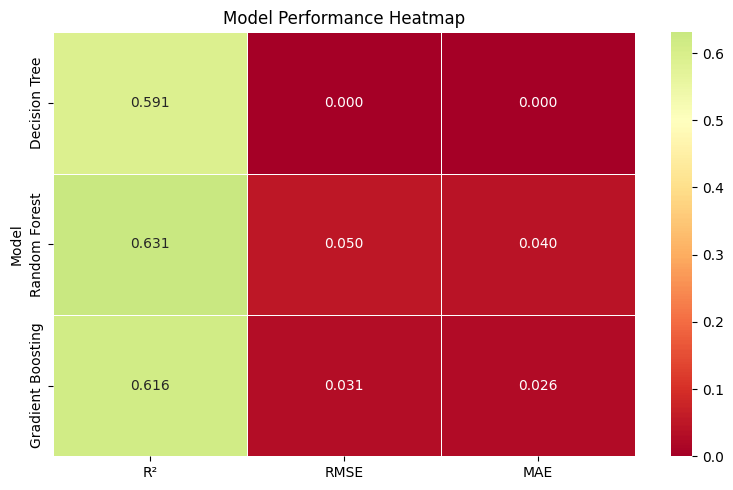

In [29]:

metrics_data = comparison[['Model', 'R²', 'RMSE', 'MAE']].copy()
for metric in ['RMSE', 'MAE']:
    max_val = metrics_data[metric].max()
    metrics_data[metric] = 1 - (metrics_data[metric] / max_val)

metrics_data.set_index('Model', inplace=True)

plt.figure(figsize=(8, 5))
sns.heatmap(metrics_data, annot=True, cmap='RdYlGn', center=0.5, fmt='.3f', linewidths=0.5)
plt.title('Model Performance Heatmap')
plt.tight_layout()
plt.show()


# Final Findings

In [ ]:
# MODEL PERFORMANCE
# Random Forest is best (R² = 0.6309)

# Gradient Boosting is second best (R² = 0.6158)

# Decision Tree is lowest (R² = 0.5909)

# All 3 models perform well (R² > 0.59)

# FEATURE IMPORTANCE
# AI_ROI_Percent is most important (98%)

# Year has almost no importance (1%)

# Revenue_USD has almost no importance (1%)

# Only AI_ROI actually matters for prediction

# ERROR ANALYSIS
# Random Forest has lowest error (MAE = 11.26, RMSE = 13.07)

# Decision Tree has highest error (MAE = 11.72, RMSE = 13.76)

# Residuals are symmetric (no bias in predictions)

# ENSEMBLE LEARNING
# Random Forest (Bagging) works better than Gradient Boosting

# Ensemble methods reduce overfitting

# Random Forest handles non-linear data well



